# Proyecto Final - Clasificación Binaria

**Tema:** Diagnóstico de cáncer de mama: predecir si un tumor es benigno o maligno.

**Dataset:** Breast Cancer Wisconsin (Diagnostic), UCI Machine Learning Repository.

Este notebook descarga el dataset desde el enlace de UCI, lo convierte a CSV, entrena Regresión Logística y Red Neuronal, hace tuneo de hiperparámetros, matriz de confusión y exactitud.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import joblib
import json
from pathlib import Path

Path('data').mkdir(exist_ok=True)
Path('model').mkdir(exist_ok=True)

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data'
columnas = ['id', 'diagnosis'] + [
    f'{stat} {feature}'
    for stat in ['mean', 'error', 'worst']
    for feature in ['radius','texture','perimeter','area','smoothness','compactness','concavity','concave points','symmetry','fractal dimension']
]

df = pd.read_csv(url, header=None, names=columnas)
df = df.drop(columns=['id'])
df.to_csv('data/breast_cancer_wisconsin_diagnostic.csv', index=False)
df.head()

,diagnosis,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
print('Filas y columnas:', df.shape)
print(df['diagnosis'].value_counts())
df.describe().T.head()

Filas y columnas: (569, 31)
diagnosis
B    357
M    212
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634


## 2. Dividir en X y y, entrenamiento y prueba

In [4]:
X = df.drop(columns=['diagnosis'])
y = (df['diagnosis'] == 'M').astype(int)  # 1 = maligno, 0 = benigno

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Entrenamiento:', X_train.shape)
print('Prueba:', X_test.shape)

Entrenamiento: (455, 30)
Prueba: (114, 30)


## 3. Modelo 1: Regresión Logística con tuneo

In [5]:
log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=10000))
])

log_params = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['lbfgs'],
    'model__penalty': ['l2']
}

log_search = RandomizedSearchCV(
    log_model, log_params, n_iter=5, cv=3, scoring='accuracy', random_state=42
)
log_search.fit(X_train, y_train)

print('Mejores parametros:', log_search.best_params_)
print('Mejor accuracy CV:', log_search.best_score_)

c:\Users\Yesid Andres\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Yesid Andres\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Yesid Andres\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarnin

Mejores parametros: {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': 1}
Mejor accuracy CV: 0.9758191007319623


c:\Users\Yesid Andres\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Yesid Andres\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Yesid Andres\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarnin

## 4. Modelo 2: Red Neuronal con tuneo

In [6]:
mlp_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(max_iter=1000, random_state=42, early_stopping=True))
])

mlp_params = {
    'model__hidden_layer_sizes': [(32,), (64,), (64, 32)],
    'model__activation': ['relu', 'tanh'],
    'model__alpha': [0.0001, 0.001, 0.01]
}

mlp_search = RandomizedSearchCV(
    mlp_model, mlp_params, n_iter=6, cv=3, scoring='accuracy', random_state=42
)
mlp_search.fit(X_train, y_train)

print('Mejores parametros:', mlp_search.best_params_)
print('Mejor accuracy CV:', mlp_search.best_score_)

Mejores parametros: {'model__hidden_layer_sizes': (32,), 'model__alpha': 0.0001, 'model__activation': 'relu'}
Mejor accuracy CV: 0.918757987684443


## 5. Evaluación: matriz de confusión y exactitud

Modelo: Regresion Logistica
Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

     Benigno       0.96      0.99      0.97        72
     Maligno       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



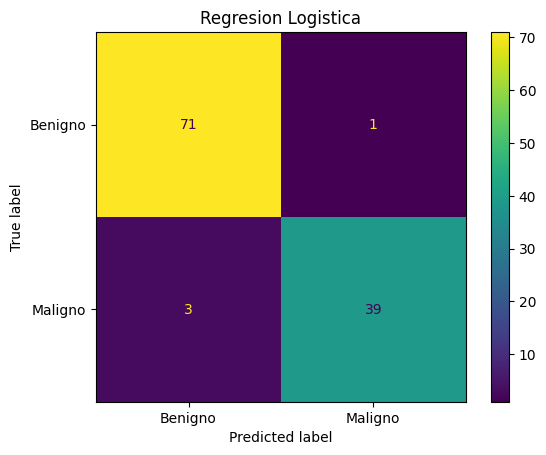

Modelo: Red Neuronal
Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

     Benigno       0.99      0.99      0.99        72
     Maligno       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



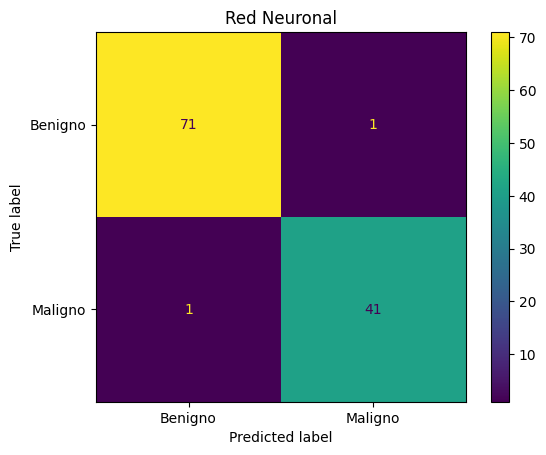

In [17]:
modelos = {
    'Regresion Logistica': log_search.best_estimator_,
    'Red Neuronal': mlp_search.best_estimator_
}

resultados = {}
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultados[nombre] = acc
    print('Modelo:', nombre)
    print('Accuracy:', acc)
    print(classification_report(y_test, y_pred, target_names=['Benigno','Maligno']))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Benigno','Maligno'])
    plt.title(nombre)
    plt.show()

## 6. Guardar el mejor modelo y parámetros para la página web

In [18]:
mejor_nombre = max(resultados, key=resultados.get)
mejor_modelo = modelos[mejor_nombre]
joblib.dump(mejor_modelo, 'model/best_model.joblib')
log_web = log_search.best_estimator_
scaler = log_web.named_steps['scaler']
lr = log_web.named_steps['model']
web_params = {
    'features': list(X.columns),
    'mean': scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist(),
    'coef': lr.coef_[0].tolist(),
    'intercept': float(lr.intercept_[0]),
    'defaults': X.median().to_dict(),
    'accuracy': float(resultados['Regresion Logistica'])
}
with open('model/logistic_web_params.json', 'w', encoding='utf-8') as f:
    json.dump(web_params, f, indent=2)

print('Mejor modelo:', mejor_nombre)
print('Archivos guardados en /model')

Mejor modelo: Red Neuronal
Archivos guardados en /model
